# Blood Donation Prediction using Machine Learning

# Problem Statement
### To build a machine learning model that predicts whether a donor will donate blood in March 2007 based on their historical blood donation records.

## Domain Analysis

### Domain

**Healthcare – Blood Donation Prediction**

### Background

Blood transfusion plays a vital role in saving lives by supporting patients undergoing major surgeries, treating serious injuries, and managing various medical conditions. Maintaining an adequate blood supply is a continuous challenge for blood banks, as the demand for blood is often unpredictable. According to the project description, the dataset was collected from a mobile blood donation vehicle in Taiwan that organized blood donation campaigns at different universities. The objective is to predict whether a donor will donate blood during the next campaign in March 2007.

### Business Problem

Blood banks need an efficient way to identify donors who are likely to participate in future blood donation campaigns. Contacting every registered donor requires significant time and resources. A predictive model can help prioritize donors who are more likely to donate, improving the effectiveness of blood donation campaigns.

### Dataset Features

The prediction is based on the following donor attributes:

* Months since Last Donation        - Number of months since the donor's most recent blood donation.
* Number of Donations               - Total number of blood donations made by the donor.
* Total Volume Donated (c.c.)       - Total amount of blood donated by the donor (in cubic centimeters).
* Months since First Donation       - Number of months since the donor's first blood donation.

The target variable is:

* **Made Donation in March 2007** (1 = Donated, 0 = Did Not Donate)

### Business Impact

A reliable prediction model can help blood banks:

* Identify potential blood donors more effectively.
* Improve the success of blood donation campaigns.
* Optimize time and operational resources.
* Maintain a stable blood supply to meet healthcare needs.


In [85]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [86]:
# Load the data
data=pd.read_csv('Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv')

In [87]:
data

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0
...,...,...,...,...,...,...
571,698,23,1,250,23,0
572,433,16,3,750,86,0
573,360,21,2,500,52,0
574,541,39,1,250,39,0


In [88]:
# Dropping the unwanted column
data.drop('Unnamed: 0', axis=1, inplace=True)

In [89]:
# Display the first 5 rows of the dataset
data.head()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


In [90]:
# Display the last 5 rows of the dataset
data.tail()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
571,23,1,250,23,0
572,16,3,750,86,0
573,21,2,500,52,0
574,39,1,250,39,0
575,72,1,250,72,0


In [91]:
# Check number of rows and columns
data.shape

(576, 5)

In [92]:
# Display all columns
data.columns

Index(['Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='object')

In [93]:
# Display dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Months since Last Donation   576 non-null    int64
 1   Number of Donations          576 non-null    int64
 2   Total Volume Donated (c.c.)  576 non-null    int64
 3   Months since First Donation  576 non-null    int64
 4   Made Donation in March 2007  576 non-null    int64
dtypes: int64(5)
memory usage: 22.6 KB


In [94]:
# Generate descriptive statistics
data.describe()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000
mean,9.439236,5.427083,1356.770833,34.050347,0.239583
std,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.000000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,49.250000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


#### Insight:
- The statistical summary shows that donor behavior varies significantly in terms of donation frequency and donation history. 
- The target variable is imbalanced, with only 24% of donors making a donation in March 2007, making it suitable for predictive analysis.

In [95]:
# Find unique values in the target variable
data['Made Donation in March 2007'].unique()

array([1, 0])

In [96]:
# Check the count of donors and non-donors in the target variable
data['Made Donation in March 2007'].value_counts()

Made Donation in March 2007
0    438
1    138
Name: count, dtype: int64

#### The data is imbalanced. Most donors (438) did not donate in March 2007, while only 138 donors donated during that period.

In [97]:
data['Made Donation in March 2007'].value_counts(normalize=True)*100

Made Donation in March 2007
0    76.041667
1    23.958333
Name: proportion, dtype: float64

#### Approximately 76% of donors did not donate in March 2007, while only 24% donated, indicating class imbalance.

In [98]:
# Check for missing values
data.isnull().sum()

Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

#### No missing values are present in the dataset. Therefore, data cleaning requirements are minimal, and the dataset is ready for further analysis and preprocessing.

# Exploratory Data Analysis

## Univariate Analysis

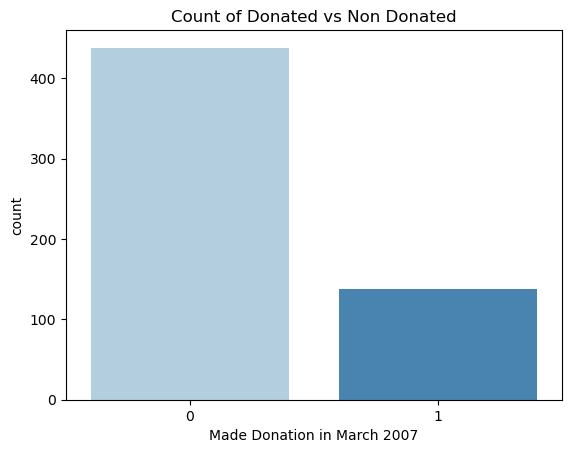

In [99]:
# Visualize the distribution of the target variable
sns.countplot(x=data['Made Donation in March 2007'], palette='Blues')
plt.title("Count of Donated vs Non Donated")
plt.show()

### Insight:
- The visualization clearly shows that non-donors (Class 0) significantly outnumber donors (Class 1).
- Class imbalance should be considered during model evaluation and model selection.

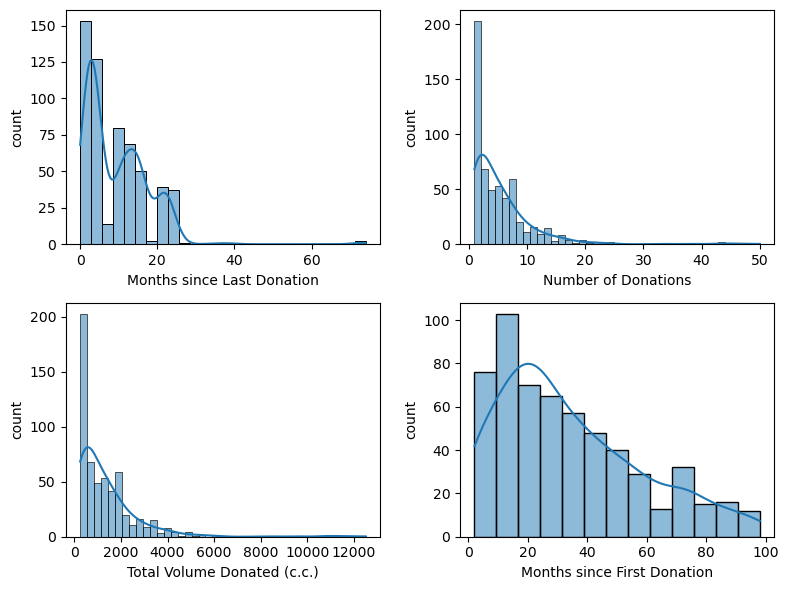

In [100]:
# Visualize the distribution of numerical features
plt.figure(figsize=(8,6), facecolor='white')
plotnumber = 1

for column in data.drop('Made Donation in March 2007', axis=1).columns:
    plt.subplot(2,2,plotnumber)
    sns.histplot(data[column], kde=True)
    plt.xlabel(column,fontsize=10)
    plt.ylabel("count",fontsize=10)
    plotnumber += 1

plt.tight_layout()
plt.show()

#### Insight:
- Most features are positively right skewed, indicating that a majority of donors have lower donation frequency and donation volume, while a few donors contribute significantly more.
- The feature "Months since First Donation" shows a wider spread, suggesting the dataset contains both new and long-term donors.

## Outlier Analysis

- Boxplots were used to examine the numerical features for potential outliers.
- Although a few outliers were observed, they were retained because they represent genuine donor records rather than data entry errors.
- Retaining these values helps preserve the original data and the real-world donor behavior.

## Bivariate Analysis

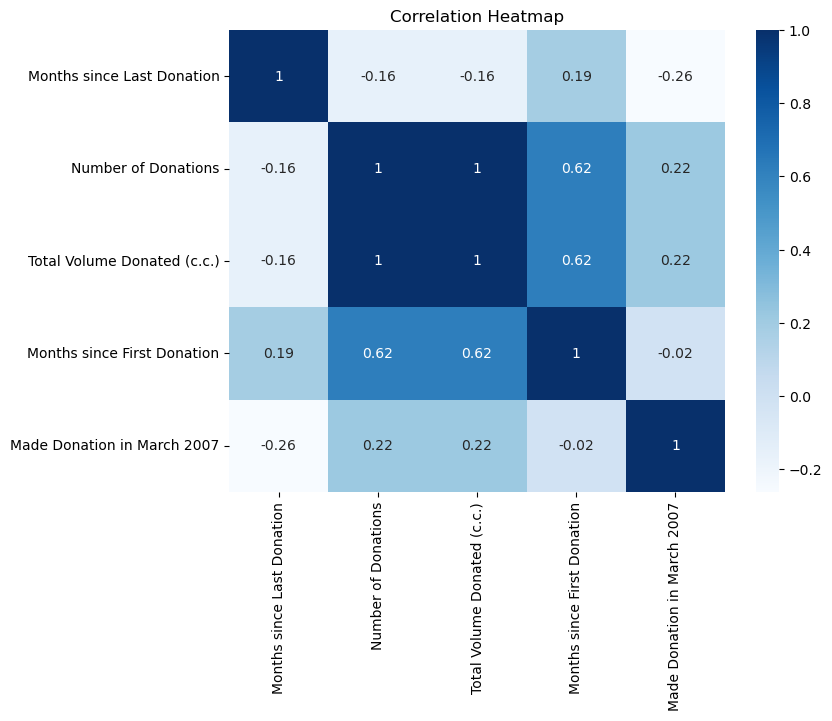

In [101]:
# Analyze the relationship between features using a correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

#### Insights:
- Number of Donations and Total Volume Donated are perfectly correlated, indicating that both features contain similar information.
- Months since Last Donation has a negative correlation with the target variable, indicating that donors who donated recently are more likely to make future donations.
- Number of Donations and Months since First Donation show a positive correlation, indicating that long-term donors tend to make more donations.

In [102]:
# Drop redundant feature
data.drop('Total Volume Donated (c.c.)', axis=1, inplace=True)

#### Correlation analysis revealed that Total Volume Donated (c.c.) and Number of Donations have a perfect correlation of 1.0. Since Total Volume Donated is derived from Number of Donations, it was removed to reduce redundancy and multicollinearity.

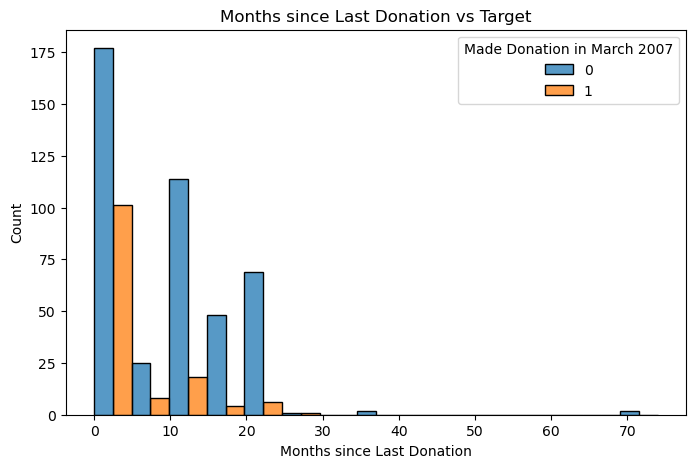

In [103]:
# Analysing relationship between Months since last donation and Made donation in 2007
plt.figure(figsize=(8,5))
sns.histplot(x='Months since Last Donation',hue='Made Donation in March 2007',data=data, bins=15, multiple='dodge' )
plt.title("Months since Last Donation vs Target")
plt.show()

#### Insight:
- As the number of Months since Last Donation increases, the probability of donating in March 2007 decreases.
- Donors who made a recent donation are more likely to donate again in March 2007.

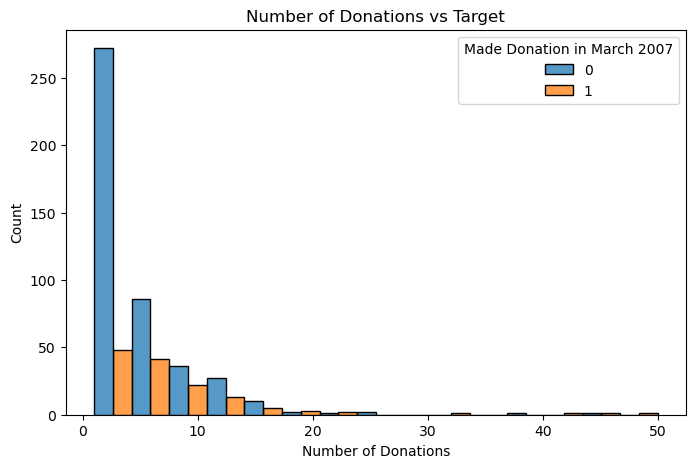

In [104]:
# Analysing relationship between Number of Donations and Made donation in 2007
plt.figure(figsize=(8,5))
sns.histplot(x='Number of Donations',hue='Made Donation in March 2007',data=data, bins=15, multiple='dodge' )
plt.title("Number of Donations vs Target")
plt.show()

#### Insight:
- Donors with a higher number of past donations are more likely to donate again.

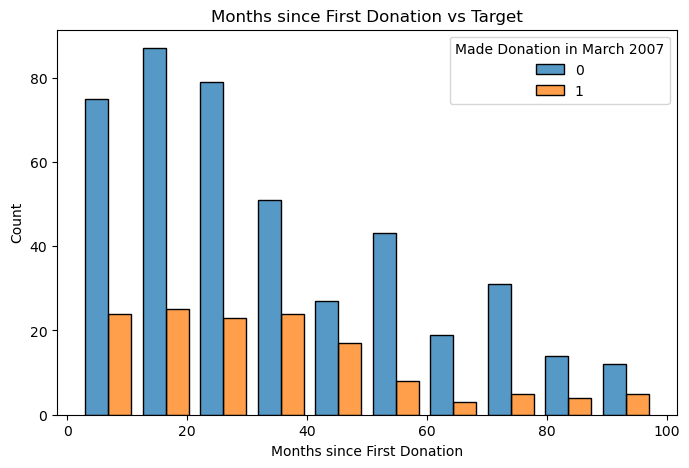

In [105]:
# Analysing relationship between Months since First Donation and Made Donation in March 2007
plt.figure(figsize=(8,5))
sns.histplot(x='Months since First Donation', hue='Made Donation in March 2007', data=data, bins=10, shrink=0.8, multiple='dodge')
plt.title("Months since First Donation vs Target")
plt.show()

#### Insight
- Donors with a higher number of past donations are more likely to donate again, showing that repeated donation history increases the probability of future donation.

## Data Preprocessing

In [106]:
# Check for duplicates
data.duplicated().sum()

np.int64(153)

In [107]:
data = data.drop_duplicates()

In [108]:
data.duplicated().sum()

np.int64(0)

In [109]:
data.shape

(423, 4)

# Model Building

### Split Features and Target

In [110]:
# split data into x and y
x = data.drop('Made Donation in March 2007', axis=1)
y = data['Made Donation in March 2007']

### Train-Test Split

In [111]:
# split data for training and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#### The dataset was split into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [112]:
# Check the Shapes
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (338, 3)
x_test shape: (85, 3)
y_train shape: (338,)
y_test shape: (85,)


### Feature Scaling
* Feature scaling was applied using StandardScaler because Logistic Regression and K-Nearest Neighbors (KNN) are sensitive to the scale of input features. Decision Tree and Random Forest do not require feature scaling.

In [113]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Evaluation Metric Selection

#### In this project, the objective is to predict whether a donor will donate blood in March 2007.

#### Since the goal is to identify as many potential donors as possible, **Recall is considered the primary evaluation metric.**

#### Recall measures the proportion of actual donors that are correctly identified by the model.

#### A False Negative occurs when a donor who would actually donate blood is predicted as a non-donor. Missing such donors may result in lost donation opportunities for the blood bank.

#### Therefore, minimizing False Negatives and maximizing Recall is more important than achieving high Accuracy alone. For this reason, Recall is used as the primary metric for model evaluation and hyperparameter tuning.

# LOGISTIC REGRESSION

In [114]:
# Train the Logistic Regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, class_weight='balanced')

lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [115]:
# Predict whether a donor will donate blood in March 2007
y_pred_lr = lr.predict(x_test_scaled)

In [116]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

### Accuracy

In [117]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)

Accuracy: 0.5411764705882353


### Precision

In [118]:
lr_precision = precision_score(y_test, y_pred_lr)

print("Precision:", lr_precision)

Precision: 0.34782608695652173


### Recall

In [121]:
lr_recall=recall_score(y_test,y_pred_lr)

print("Recall:", lr_recall)

Recall: 0.64


### F1-Score

In [122]:
lr_f1=f1_score(y_test,y_pred_lr)

print("F1_Score:", lr_f1)

F1_Score: 0.4507042253521127


### Classification Report

In [123]:
cr=classification_report(y_test,y_pred_lr)

print(cr)

              precision    recall  f1-score   support

           0       0.77      0.50      0.61        60
           1       0.35      0.64      0.45        25

    accuracy                           0.54        85
   macro avg       0.56      0.57      0.53        85
weighted avg       0.65      0.54      0.56        85



### Confusion Matrix

In [124]:
cm=confusion_matrix(y_test,y_pred_lr)

print("Confusion matrix:\n",cm)

Confusion matrix:
 [[30 30]
 [ 9 16]]


### Confusion Matrix Heatmap

Confusion Matrix:
[[30 30]
 [ 9 16]]

Matrix Breakdown:
True Negative (TN): 30
False Positive (FP): 30
False Negative (FN): 9
True Positive (TP): 16


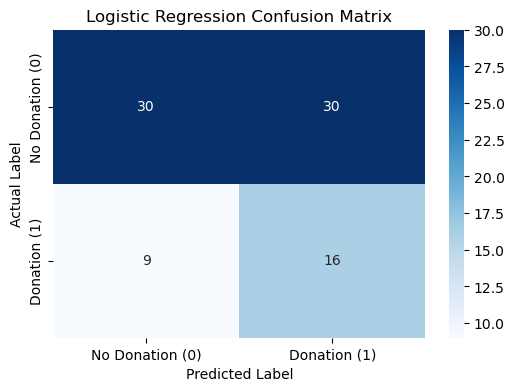

In [125]:
# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Extract values
TN, FP, FN, TP = cm_lr.ravel()

print("Confusion Matrix:")
print(cm_lr)

print("\nMatrix Breakdown:")
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Plot Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

### Insight

- TN = 30, indicating 30 non-donors were correctly identified.
- FP = 30, meaning 30 non-donors were incorrectly classified as donors.
- FN = 9, indicating only 9 actual donors were missed.
- TP = 16, showing 16 actual donors were correctly identified.

The model achieved a high recall of 64.0%, successfully identifying most potential donors. Although the number of false positives increased, minimizing false negatives is more important in blood donation prediction, making this model suitable for donor identification.


#### Logistic Regression achieved an accuracy of 54% with a recall of 64% for the donor class after applying class balancing. The model was effective in identifying potential donors, though the overall accuracy was moderate. Further models will be evaluated and compared to determine the best-performing approach.

# DECISION TREE

In [126]:
# Import and Train the Model
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [127]:
# Predict whether a donor will donate blood in March 2007
y_pred_dt = dt.predict(x_test)

### Accuracy

In [128]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.5764705882352941


### Recall

In [129]:
dt_recall = recall_score(y_test, y_pred_dt)

print("Recall:", dt_recall)

Recall: 0.32


### Classification Report

In [130]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.71      0.68      0.69        60
           1       0.30      0.32      0.31        25

    accuracy                           0.58        85
   macro avg       0.50      0.50      0.50        85
weighted avg       0.59      0.58      0.58        85



### Confusion Matrix

In [131]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[41 19]
 [17  8]]


### Confusion Matrix Heatmap

Confusion Matrix:
[[41 19]
 [17  8]]

Matrix Breakdown:
True Negative (TN): 41
False Positive (FP): 19
False Negative (FN): 17
True Positive (TP): 8


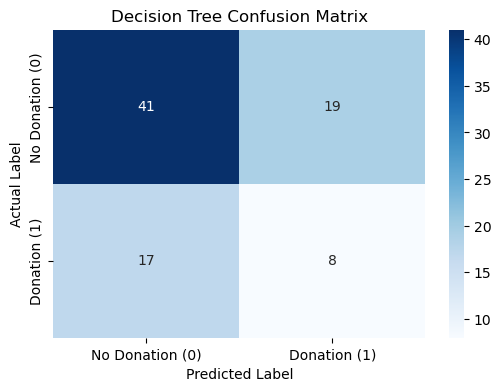

In [132]:
# Create confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Extract values
TN, FP, FN, TP = cm_dt.ravel()

print("Confusion Matrix:")
print(cm_dt)

print("\nMatrix Breakdown:")
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Plot Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

### Insight
- TN = Correctly identified 41 non-donors.
- FP = Incorrectly classified 19 non-donors as donors.
- FN = Missed 17 actual donors.
- TP = Correctly identified only 8 actual donors.

* The Decision Tree correctly identified 41 non-donors and 8 donors. But it failed to identify 17 actual donors, resulting in a recall of 32.0%.
* Compared to Logistic Regression, the model missed a larger number of donors.
* Since identifying potential donors is the primary objective of this project, the current Decision Tree model is less suitable than Logistic Regression.

* The model correctly identified donors and non-donors but still missed some actual donors. Since donor identification is the primary objective, recall will be further improved through hyperparameter tuning.

### Recall was selected as the scoring metric during hyperparameter tuning because the primary objective of this project is to identify as many potential blood donors as possible. Minimizing false negatives is important since missing a potential donor could result in lost donation opportunities.

## Hyperparameter Tuning of Decision Tree

In [133]:
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'    # Using class_weight='balanced' to handle class imbalance.
)
from sklearn.model_selection import GridSearchCV

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=params,
    scoring='recall',        # Hyperparameter Tuning using Recall Score
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_dt.fit(x_train, y_train)
print("Best Parameters:")    # Get the best parameters
print(grid_dt.best_params_)

print("\nBest Recall Score:")
print(grid_dt.best_score_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Best Recall Score:
0.6912280701754386


In [134]:
# passing best parameter to decision tree
dt1 = DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=4, min_samples_split=2, random_state=42, class_weight='balanced')

In [135]:
# training model with best parameter
dt1.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [136]:
# predicting the model
y_hat1=dt1.predict(x_test) 
y_hat1

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1])

### Accuracy After Tuning

In [137]:
dt_tuned_accuracy = accuracy_score(y_test,y_hat1)

print("Accuracy:", dt_tuned_accuracy)

Accuracy: 0.6235294117647059


### Recall After Tuning

In [138]:
dt_tuned_recall = recall_score(y_test, y_hat1)

print("Recall:", dt_tuned_recall)

Recall: 0.6


### Precision After Tuning

In [139]:
dt_tuned_precision = precision_score(y_test, y_hat1)

print("Precision:", dt_tuned_precision)

Precision: 0.40540540540540543


### F1 Score After Tuning

In [140]:
dt_tuned_f1 = f1_score(y_test, y_hat1)

print("F1 Score:", dt_tuned_f1)

F1 Score: 0.4838709677419355


### Classification Report

In [141]:
print(classification_report(y_test,y_hat1)) # it will give precision,recall,f1 scores and accuracy

              precision    recall  f1-score   support

           0       0.79      0.63      0.70        60
           1       0.41      0.60      0.48        25

    accuracy                           0.62        85
   macro avg       0.60      0.62      0.59        85
weighted avg       0.68      0.62      0.64        85



### Confusion Matrix After Hyperparameter tuning

In [142]:
cm_dt_tuned = confusion_matrix(y_test, y_hat1)

print(cm_dt_tuned)

[[38 22]
 [10 15]]


### Confusion Matrix Heatmap After Hyperparameter tuning

Confusion Matrix:
[[38 22]
 [10 15]]

Matrix Breakdown:
True Negative (TN): 38
False Positive (FP): 22
False Negative (FN): 10
True Positive (TP): 15


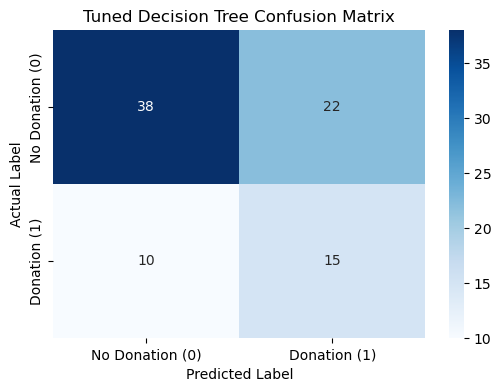

In [143]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_dt_tuned = confusion_matrix(y_test, y_hat1)

# Extract values
TN, FP, FN, TP = cm_dt_tuned.ravel()

print("Confusion Matrix:")
print(cm_dt_tuned)

print("\nMatrix Breakdown:")
print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

# Plot Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_dt_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('Tuned Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

### Insight

* After hyperparameter tuning, the Decision Tree model showed significant improvement in identifying donors. The model achieved a recall of 60.0%, meaning it correctly identified most actual donors. The accuracy improved to 62.4%, and the F1-score increased to 0.484, indicating a better balance between precision and recall. Therefore, the tuned Decision Tree model performs considerably better than the initial Decision Tree model.

#### The Tuned Decision Tree achieved an accuracy of **62.4%**, a recall of **60.0%**, and an F1-score of **0.484** after hyperparameter tuning. The model showed improved performance compared to the initial Decision Tree, providing a better balance between correctly identifying potential donors and overall classification performance. Further models will be evaluated and compared to determine the best-performing approach.

# RANDOM FOREST

In [144]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced' # # Using class_weight='balanced' to handle class imbalance.
)

rf.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
y_pred_rf = rf.predict(x_test)   # testing the model

### Accuracy

In [146]:
rf_acc = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", rf_acc)

Accuracy: 0.6823529411764706


### Recall

In [147]:
dt_tuned_recall = recall_score(y_test, y_pred_rf)

print("Recall:", dt_tuned_recall)

Recall: 0.36


### Classification Report

In [148]:
print(classification_report(y_test,y_pred_rf))   # it will give precision,recall,f1 scores and accuracy

              precision    recall  f1-score   support

           0       0.75      0.82      0.78        60
           1       0.45      0.36      0.40        25

    accuracy                           0.68        85
   macro avg       0.60      0.59      0.59        85
weighted avg       0.66      0.68      0.67        85



### Confusion Matrix

In [149]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[49 11]
 [16  9]]


### Confusion Matrix Heatmap

TN: 49
FP: 11
FN: 16
TP: 9


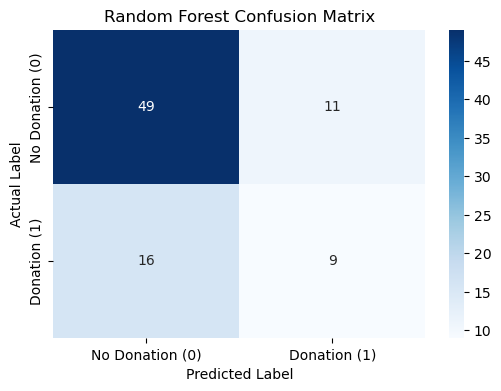

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt

TN, FP, FN, TP = cm_rf.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

### Insight
- TN = Correctly identified 49 non-donors.
- FP = Incorrectly classified 11 non-donors as donors.
- FN = Failed to identify 16 actual donors.
- TP = Correctly identified 9 actual donors.

#### Although the Random Forest model correctly classified most non-donors, it missed 16 actual donors. The model showed a balanced performance in identifying both donor and non-donor classes. Further improvement will be explored through hyperparameter tuning to increase donor detection and reduce false negatives.

## Hyperparameters Tuning of RandomForest

In [151]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_clf1 = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

random_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_cv = RandomizedSearchCV(
    estimator=rf_clf1,
    param_distributions=random_grid,
    n_iter=20,
    scoring='recall',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rf_cv.fit(x_train, y_train)

print("Best Parameters:")
print(rf_cv.best_params_)

print("\nBest Recall Score:")
print(rf_cv.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}

Best Recall Score:
0.6344086021505376


In [152]:
# passing best parameter to randomforest
rf_clf2 = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='log2',
    max_depth=20,
    class_weight='balanced',
    random_state=42
)

rf_clf2.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Accuracy After Tuning

In [153]:
y_predict=rf_clf2.predict(x_test)    # testing
rf_tuned_accur = accuracy_score(y_test,y_predict)   # checking performance
print("Accuracy:", rf_tuned_accur)

Accuracy: 0.6705882352941176


### Recall after tuning

In [154]:
rf_tuned_recall = recall_score(y_test, y_predict)

print("Recall:", rf_tuned_recall)

Recall: 0.6


### Precision After Tuning

In [155]:
rf_tuned_precision = precision_score(y_test, y_predict)
print("Precision:", rf_tuned_precision)

Precision: 0.45454545454545453


### F1 Score After Tuning

In [156]:
rf_tuned_f1 = f1_score(y_test, y_predict)
print("F1 Score:", rf_tuned_f1)

F1 Score: 0.5172413793103449


In [157]:
print(classification_report(y_test,y_predict))   # it will give precision,recall,f1 scores and accuracy

              precision    recall  f1-score   support

           0       0.81      0.70      0.75        60
           1       0.45      0.60      0.52        25

    accuracy                           0.67        85
   macro avg       0.63      0.65      0.63        85
weighted avg       0.70      0.67      0.68        85



### Confusion Matrix After Tuning

In [158]:
cm_rf_tuned = confusion_matrix(y_test, y_predict)

print(cm_rf_tuned)

[[42 18]
 [10 15]]


### Confusion Matrix Heatmap After Tuning

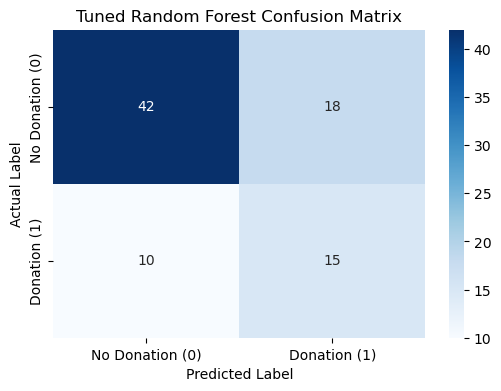

In [159]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

### Insight

* After hyperparameter tuning, the Random Forest model showed improved performance in identifying potential donors. The model achieved better recall while maintaining good overall accuracy and F1-score. The tuned Random Forest will be compared with Logistic Regression, Decision Tree, and KNN to determine the most suitable model for deployment.

#### The Tuned Random Forest achieved an accuracy of **67.0%**, a recall of **60.0%**, and an F1-score of **51.72** after hyperparameter tuning. The model provided balanced classification performance and showed stable results in predicting potential blood donors. Further models will be evaluated and compared to determine the best-performing approach.

# K-Nearest Neighbors (KNN)

In [160]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=25)

knn.fit(x_train_scaled, y_train)

,n_neighbors,25
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [161]:
y_pred_knn = knn.predict(x_test_scaled)

### Accuracy

In [163]:
from sklearn.metrics import accuracy_score
knn_acc = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", knn_acc)

Accuracy: 0.7411764705882353


### Recall

In [162]:
knn_recall = recall_score(y_test, y_pred_knn)

print("Recall:", knn_recall)

Recall: 0.32


### Precision 

In [164]:
knn_precision = precision_score(y_test, y_pred_knn)

print("Precision:", knn_precision)

Precision: 0.6153846153846154


### F1 Score

In [165]:
knn_f1score = f1_score(y_test, y_pred_knn)

print("f1 Score:", knn_f1score)

f1 Score: 0.42105263157894735


### Classification Report

In [166]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.76      0.92      0.83        60
           1       0.62      0.32      0.42        25

    accuracy                           0.74        85
   macro avg       0.69      0.62      0.63        85
weighted avg       0.72      0.74      0.71        85



### Confusion Matrix

In [167]:
from sklearn.metrics import confusion_matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[55  5]
 [17  8]]


### Confusion Metrics Heatmap

[[55  5]
 [17  8]]
TN: 55
FP: 5
FN: 17
TP: 8


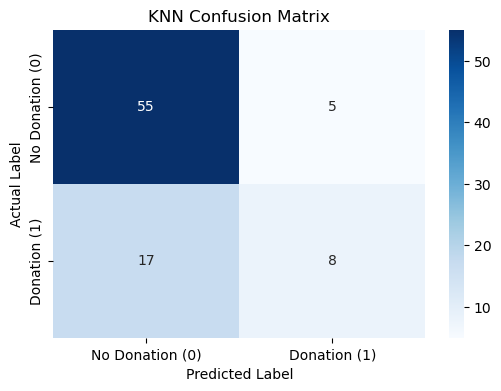

In [168]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

TN, FP, FN, TP = cm_knn.ravel()

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Donation (0)', 'Donation (1)'],
    yticklabels=['No Donation (0)', 'Donation (1)']
)

plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()


### Insight

- TN = Correctly identified 55 non-donors.
- FP = Incorrectly classified 5 non-donors as donors.
- FN = Failed to identify 17 actual donors.
- TP = Correctly identified 8 actual donors.

- The KNN model performed well in identifying non-donors, with a very low number of false positives. However, it missed 17 actual donors, which affects its ability to identify potential blood donors.
- While the model achieved strong classification for the majority class, improving donor detection remains important. Hyperparameter tuning will be performed to enhance recall and overall model performance.  

#### K-Nearest Neighbors (KNN) achieved the highest Accuracy (**74.12%**), highest Precision (**0.615**), and F1-Score (**0.421**) among all the evaluated models. However, its Recall (**0.32**) was lower than Logistic Regression, indicating that it missed more actual donors. Although KNN demonstrated strong overall classification performance, it can not be selected as the final model because the primary objective of this project is to identify as many potential blood donors as possible.

## Model Comparison

In [169]:
import pandas as pd

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Decision Tree (Tuned)', 'Random Forest (Tuned)', 'KNN'],
    'Accuracy': [lr_accuracy, dt_tuned_accuracy, rf_tuned_accur, knn_acc],
    'Precision': [lr_precision, dt_tuned_precision, rf_tuned_precision, knn_precision],
    'Recall': [lr_recall, dt_tuned_recall, rf_tuned_recall, knn_recall],
    'F1-Score': [lr_f1, dt_tuned_f1, rf_tuned_f1, knn_f1score]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.541,0.348,0.64,0.451
1,Decision Tree (Tuned),0.624,0.405,0.36,0.484
2,Random Forest (Tuned),0.671,0.455,0.60,0.517
3,KNN,0.741,0.615,0.32,0.421


## Model Comparison Summary
* Multiple machine learning models were trained and evaluated to predict whether a donor would participate in the next blood donation campaign. Since the dataset was imbalanced, model performance was evaluated using Accuracy, Precision, Recall, and F1-Score, with Recall given higher importance because the objective is to identify as many potential blood donors as possible.
  
* **Logistic Regression** achieved the highest Recall (64.00%), making it the most effective model for identifying potential blood donors.
* **Decision Tree** showed moderate performance, while the Tuned Decision Tree improved the Recall to 60.00% and F1-score to 48.40%.
* **Random Forest** produced balanced results, and the Tuned Random Forest achieved an Accuracy of 67.10%, Recall of 60.00%, and the highest F1-score (51.70%) among the tree-based models.
* **K-Nearest Neighbors (KNN)** achieved the highest Accuracy (74.12%) and Precision (61.54%), but its Recall (32.00%) was the lowest, making it less suitable for identifying potential donors.


## Conclusion
- Four machine learning models were developed and evaluated using Accuracy, Precision, Recall, and F1-Score.

- Although K-Nearest Neighbors (KNN) achieved the highest Accuracy (74.12%) and Precision (61.54%), the objective of this project was to identify as many potential blood donors as possible. Therefore, **Recall was considered the primary evaluation metric.**

### Logistic Regression achieved the highest **Recall (64.00%)**, making it the most suitable model for predicting potential blood donors. Hence, **Logistic Regression was selected as the final model for this project.**

## Challenges Faced and Techniques Used

| Challenge | Technique Used | Reason |
|-----------|----------------|--------|
| Highly correlated features | Dropped **Total Volume Donated (c.c.)** | Since it was highly correlated with **Number of Donations**, it was removed to avoid duplicate information and improve the model. |
| Presence of outliers | Outliers were retained after analysis | Since the data was original and the outliers represented real observations, they were not removed. |
| Different feature scales | Applied **StandardScaler** | Feature scaling helps Logistic Regression and KNN perform better. |
| Choosing the appropriate evaluation metric | Recall was prioritized | Identifying actual donors was more important than achieving high overall accuracy. |
| Imbalanced Target Variable | Used class_weight='balanced' in applicable models | To give more importance to the minority class, helping the model better identify potential blood donors |
| Finding the best model parameters | Used **scoring='recall'** during hyperparameter tuning | This ensured the model was optimized to identify as many potential donors as possible. |
| Selecting the best model | Compared Logistic Regression, Decision Tree, Random Forest, and KNN | Comparing multiple models helped identify the algorithm that best met the project objective. |